Consider image aplly different filters like 3X3 and 5X5 features

In [1]:
#!pip install opencv-python
#!pip install --force-reinstall "numpy<2.0" opencv-python
#!pip install --upgrade matplotlib scipy opencv-python

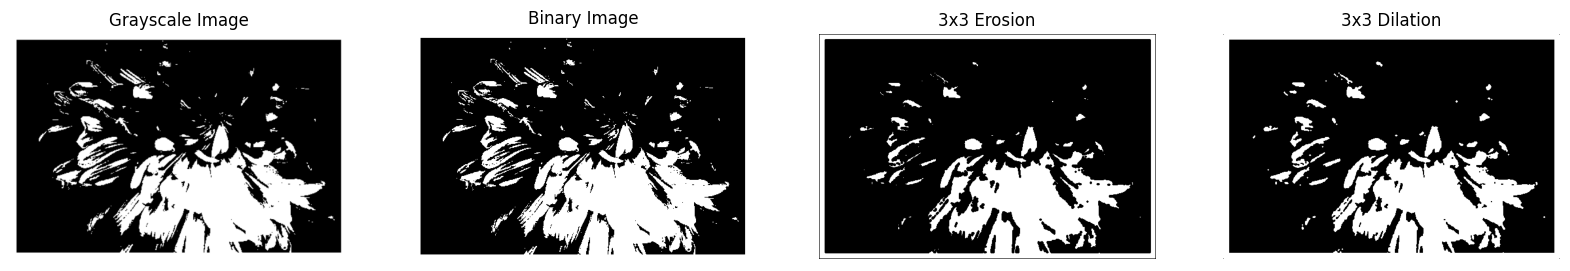

In [2]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Read the image in grayscale
image = cv2.imread(
    r"download 1.png",
    cv2.IMREAD_GRAYSCALE
)

if image is None:
    print("Image not found")

else:

    # Convert grayscale image into a binary image
    t,Bimage = cv2.threshold(image, 128, 255, cv2.THRESH_BINARY)

    # ---------------------------------------------------------
    # ADDED: Define kernel
    # ---------------------------------------------------------
    kernel=np.array([
        [0,1,0],
        [1,1,1],
        [0,1,0]
    ],dtype=np.uint8)

    # Calculate padding size
    a=int(np.ceil(len(kernel)/2))

    # Resize image
    image=cv2.resize(Bimage,(600,400))

    # Define M and N
    M,N=image.shape

    # Resize image for padding
    Zimg=cv2.resize(Bimage,(600+a,400))

    # Create empty image
    EBimage=np.zeros_like(image)

    # Define img
    img=image.copy()

    # ---------------------------------------------------------
    # EROSION
    # ---------------------------------------------------------

    # Padding the binary image
    padded_Bimage=cv2.copyMakeBorder(
        image,
        1,1,1,1,
        cv2.BORDER_CONSTANT,
        value=0
    )

    # Create erosion image
    eroded=np.zeros_like(image)

    for i in range(len(image[:,0])):
        for j in range(len(image[0,:])):

            count=0

            for x in range(kernel.shape[0]):
                for y in range(kernel.shape[1]):

                    if kernel[x,y]==1 and padded_Bimage[i+x,j+y]==255:
                        count=count+1

            if count==np.sum(kernel):
                EBimage[i,j]=255
                eroded[i,j]=255
            else:
                EBimage[i,j]=0
                eroded[i,j]=0

    # ---------------------------------------------------------
    # DILATION
    # ---------------------------------------------------------

    # Padding the binary image
    padded_eroded=cv2.copyMakeBorder(
        eroded,
        1,1,1,1,
        cv2.BORDER_CONSTANT,
        value=0
    )

    # Create dilation image
    dilated=np.zeros_like(eroded)

    for i in range(len(eroded[:,0])):
        for j in range(len(eroded[0,:])):

            count=0

            for x in range(kernel.shape[0]):
                for y in range(kernel.shape[1]):

                    if kernel[x,y]==1 and padded_eroded[i+x,j+y]==255:
                        count=count+1

            # If any kernel element overlaps with foreground,
            # set the output pixel to 255
            if count>0:
                dilated[i,j]=255
            else:
                dilated[i,j]=0

    # ---------------------------------------------------------
    # DISPLAY
    # ---------------------------------------------------------

    binary=Bimage

    plt.figure(figsize=(20,5))

    plt.subplot(1,4,1)
    plt.imshow(image, cmap="gray")
    plt.title("Grayscale Image")
    plt.axis("off")

    plt.subplot(1,4,2)
    plt.imshow(binary, cmap="gray")
    plt.title("Binary Image")
    plt.axis("off")

    plt.subplot(1,4,3)
    plt.imshow(eroded, cmap="gray")
    plt.title("3x3 Erosion")
    plt.axis("off")

    plt.subplot(1,4,4)
    plt.imshow(dilated, cmap="gray")
    plt.title("3x3 Dilation")
    plt.axis("off")

    plt.show()

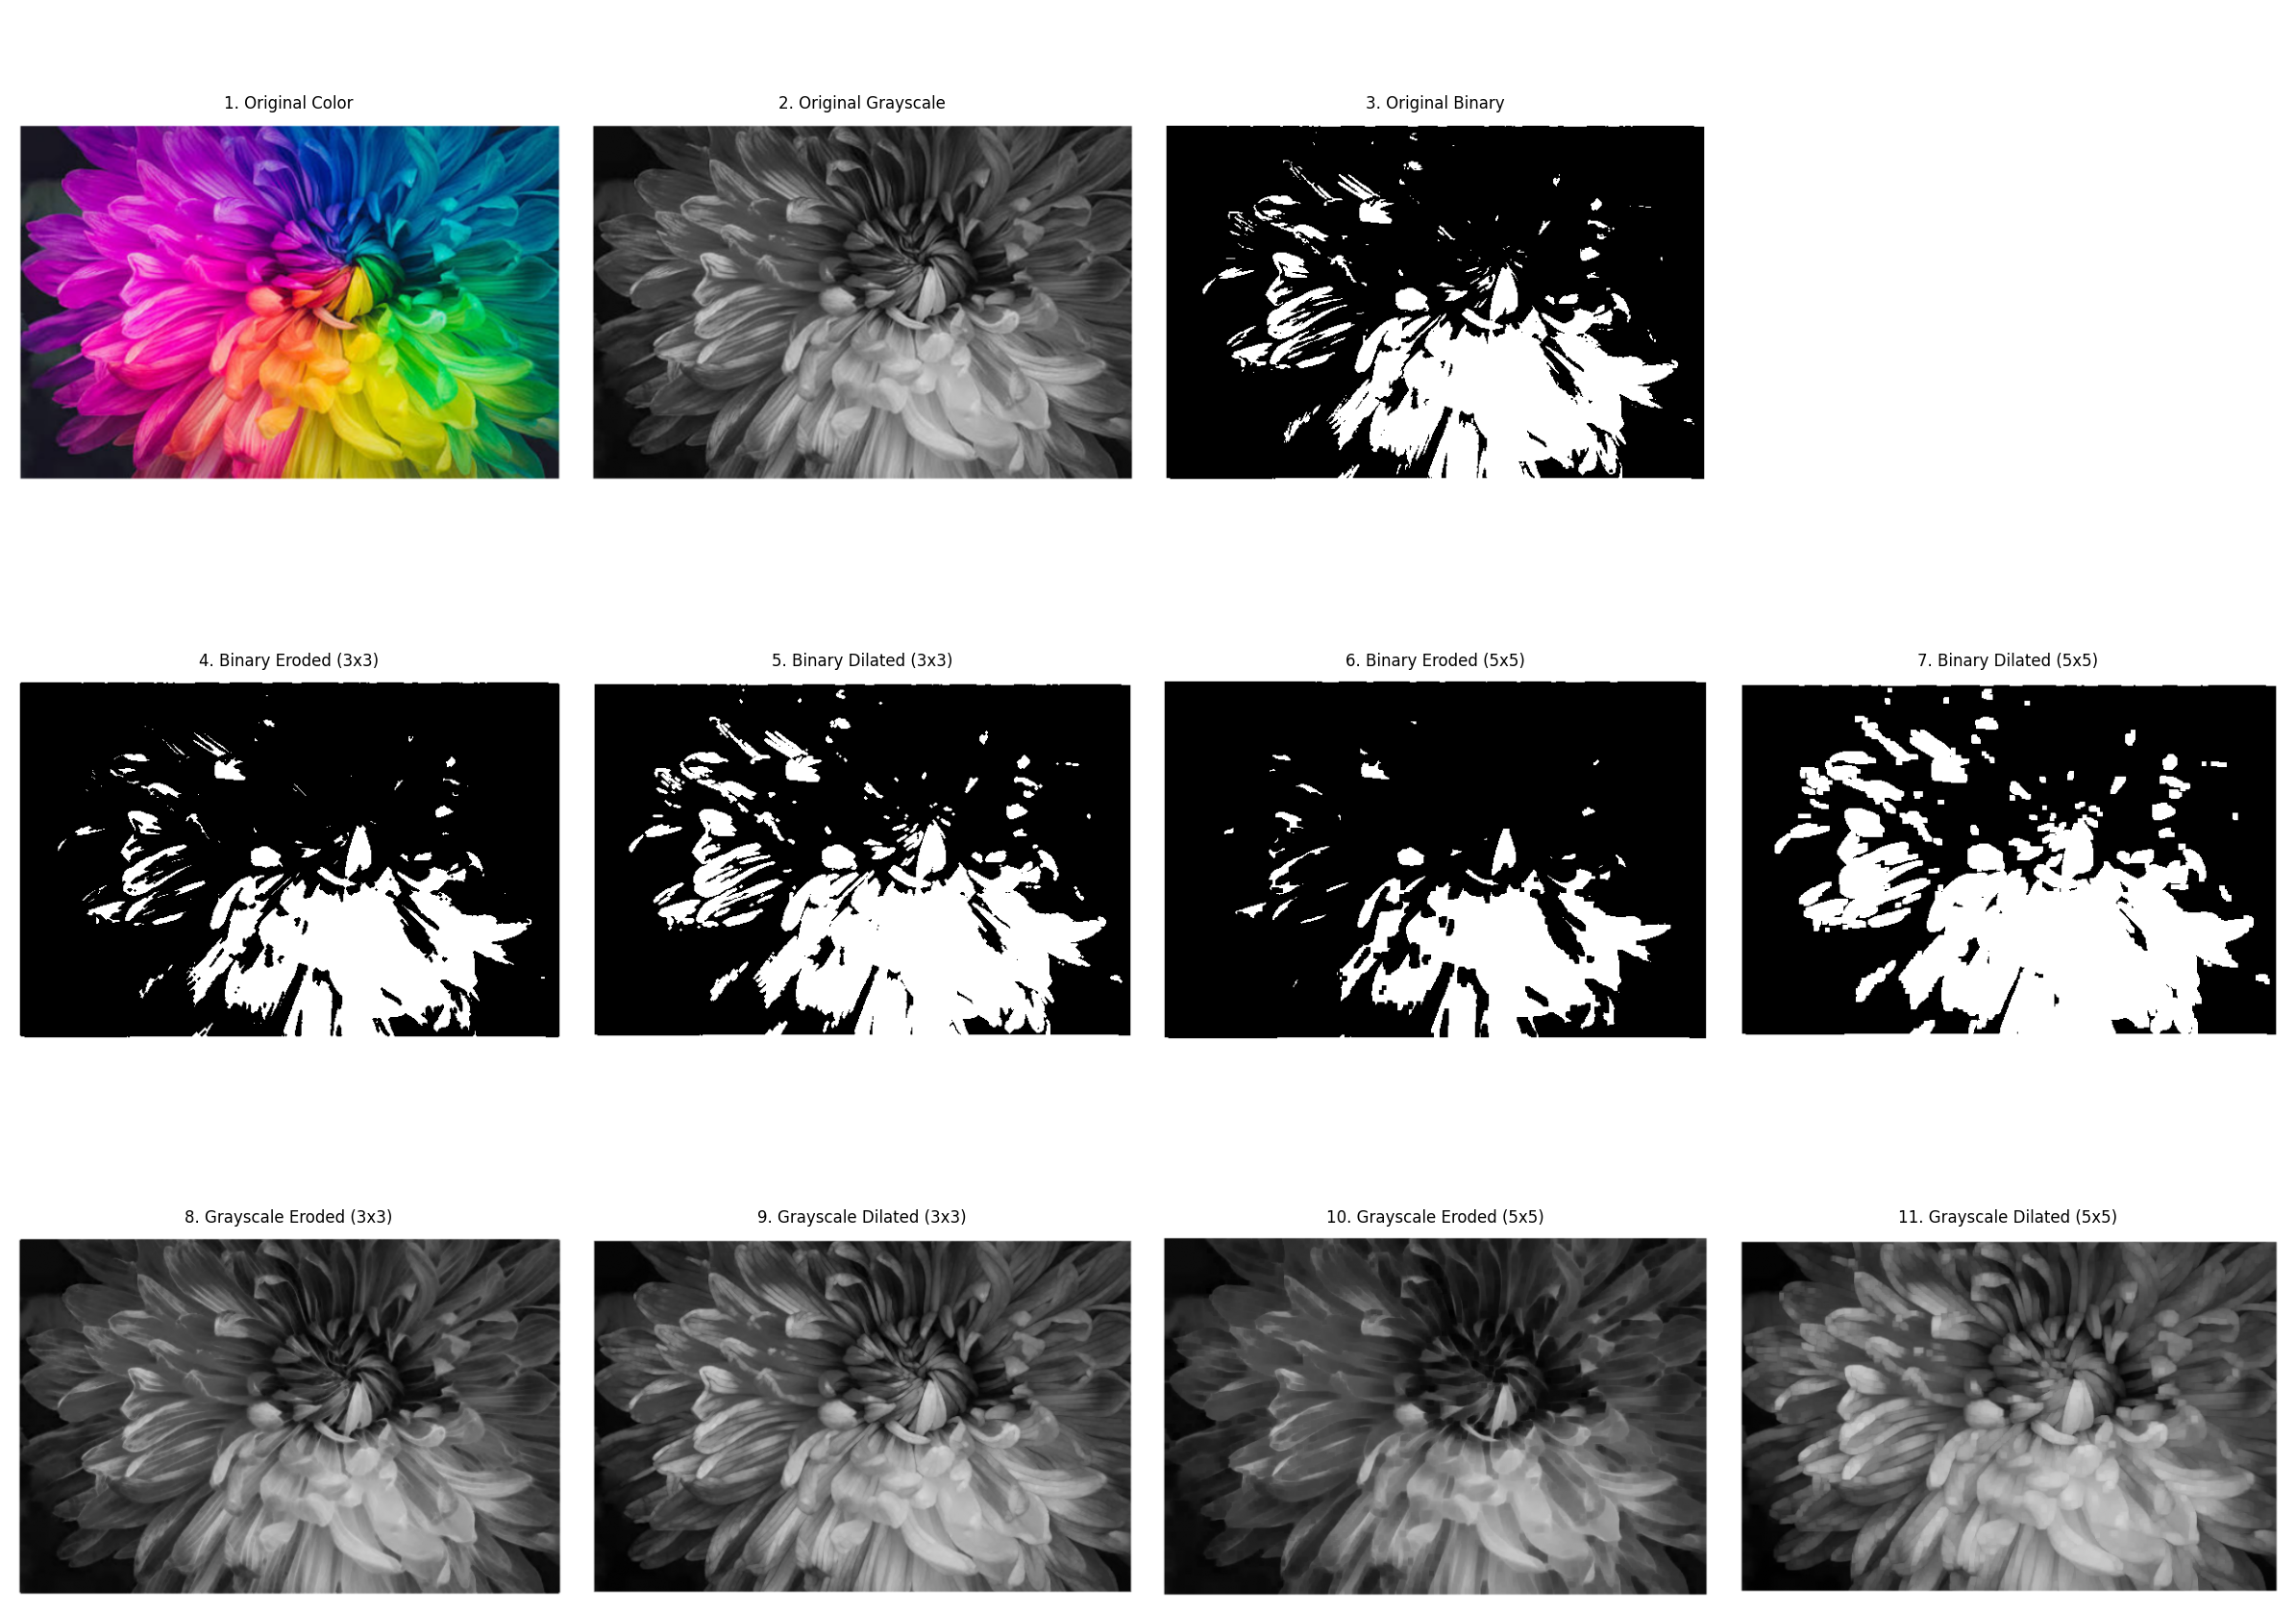

In [3]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Read the image in color
image_color = cv2.imread(
    r"/content/download 1.png",
    cv2.IMREAD_COLOR # Read as color
)

if image_color is None:
    print("Image not found. Please check the path.")
else:
    # Resize the color image for display consistency
    image_color_resized = cv2.resize(image_color, (600, 400))

    # Convert to grayscale
    image_gray = cv2.cvtColor(image_color_resized, cv2.COLOR_BGR2GRAY)

    # Convert grayscale image to binary using a global threshold
    _, image_binary = cv2.threshold(image_gray, 128, 255, cv2.THRESH_BINARY)

    # Define a 3x3 cross kernel and a 5x5 rectangular kernel
    kernel_3x3 = np.array(
        [
            [0, 1, 0],
            [1, 1, 1],
            [0, 1, 0]
        ], dtype=np.uint8
    )
    kernel_5x5 = np.ones((5,5), np.uint8) # A 5x5 rectangular kernel

    # --- Morphological Operations with 3x3 Kernel ---
    # Binary Image
    eroded_binary_3x3 = cv2.erode(image_binary, kernel_3x3, iterations=1)
    dilated_binary_3x3 = cv2.dilate(image_binary, kernel_3x3, iterations=1)
    # Grayscale Image
    eroded_gray_3x3 = cv2.erode(image_gray, kernel_3x3, iterations=1)
    dilated_gray_3x3 = cv2.dilate(image_gray, kernel_3x3, iterations=1)

    # --- Morphological Operations with 5x5 Kernel ---
    # Binary Image
    eroded_binary_5x5 = cv2.erode(image_binary, kernel_5x5, iterations=1)
    dilated_binary_5x5 = cv2.dilate(image_binary, kernel_5x5, iterations=1)
    # Grayscale Image
    eroded_gray_5x5 = cv2.erode(image_gray, kernel_5x5, iterations=1)
    dilated_gray_5x5 = cv2.dilate(image_gray, kernel_5x5, iterations=1)

    # Subplot all images for comparison
    plt.figure(figsize=(24, 18)) # Adjust figure size for more plots (3 rows, 4 columns)

    # Row 1: Original Images
    plt.subplot(3, 4, 1)
    plt.imshow(cv2.cvtColor(image_color_resized, cv2.COLOR_BGR2RGB))
    plt.title("1. Original Color")
    plt.axis("off")

    plt.subplot(3, 4, 2)
    plt.imshow(image_gray, cmap="gray")
    plt.title("2. Original Grayscale")
    plt.axis("off")

    plt.subplot(3, 4, 3)
    plt.imshow(image_binary, cmap="gray")
    plt.title("3. Original Binary")
    plt.axis("off")

    plt.subplot(3, 4, 4)
    plt.axis("off") # Empty subplot for spacing

    # Row 2: Binary Erosion/Dilation with different kernels
    plt.subplot(3, 4, 5)
    plt.imshow(eroded_binary_3x3, cmap="gray")
    plt.title("4. Binary Eroded (3x3)")
    plt.axis("off")

    plt.subplot(3, 4, 6)
    plt.imshow(dilated_binary_3x3, cmap="gray")
    plt.title("5. Binary Dilated (3x3)")
    plt.axis("off")

    plt.subplot(3, 4, 7)
    plt.imshow(eroded_binary_5x5, cmap="gray")
    plt.title("6. Binary Eroded (5x5)")
    plt.axis("off")

    plt.subplot(3, 4, 8)
    plt.imshow(dilated_binary_5x5, cmap="gray")
    plt.title("7. Binary Dilated (5x5)")
    plt.axis("off")

    # Row 3: Grayscale Erosion/Dilation with different kernels
    plt.subplot(3, 4, 9)
    plt.imshow(eroded_gray_3x3, cmap="gray")
    plt.title("8. Grayscale Eroded (3x3)")
    plt.axis("off")

    plt.subplot(3, 4, 10)
    plt.imshow(dilated_gray_3x3, cmap="gray")
    plt.title("9. Grayscale Dilated (3x3)")
    plt.axis("off")

    plt.subplot(3, 4, 11)
    plt.imshow(eroded_gray_5x5, cmap="gray")
    plt.title("10. Grayscale Eroded (5x5)")
    plt.axis("off")

    plt.subplot(3, 4, 12)
    plt.imshow(dilated_gray_5x5, cmap="gray")
    plt.title("11. Grayscale Dilated (5x5)")
    plt.axis("off")

    plt.tight_layout() # Adjust subplot parameters for a tight layout
    plt.show()